In [ ]:
import tarfile
import os

# Path to the downloaded .tar.gz file
file_path = "/home/antonio/UCSC/Research/NWM_channel_hydrofabric.tar.gz"

# Folder where the extracted files will be saved
extracted_folder = os.path.join(os.path.dirname(file_path), "NWM_channel_hydrofabric")

# Step: Extract the gdb File
with tarfile.open(file_path, 'r:gz') as tar:
    tar.extractall(path=extracted_folder)

print(f"Files extracted to the folder '{extracted_folder}'.")


In [ ]:
# Calculate the centroid of each river reach
gdf['centroid'] = gdf['geometry'].centroid

# Extract latitude and longitude from the centroid
gdf["longitude"] = gdf['centroid'].x
gdf["latitude"] = gdf['centroid'].y

# Drop the centroid column to clean up
gdf = gdf.drop(columns=['centroid'])

# Display the first few rows of the data
print(gdf.head())




In [ ]:
import os
import requests
import xarray as xr

def download_netCDF(url, save_folder):
    """
    Download a NetCDF file from a given URL and save it to a specified folder.
    
    Args:
    - url (str): The URL of the NetCDF file to download.
    - save_folder (str): The folder where the downloaded file should be saved.
    
    Returns:
    - str: The file path of the downloaded NetCDF file.
    """
    # Ensure the save folder exists
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)
    
    # Extract the filename from the URL
    filename = os.path.basename(url)
    
    # Set the path to save the file
    file_path = os.path.join(save_folder, filename)
    
    # Download the file
    response = requests.get(url, stream=True)
    with open(file_path, 'wb') as file:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
    
    return file_path

def summarize_dataset(file_path):
    """
    Summarize the dataset in a given NetCDF file.
    
    Args:
    - file_path (str): The path to the NetCDF file to summarize.
    """
    ds = xr.open_dataset(file_path)
    
    # Display global attributes
    print("Global Attributes:")
    for attr, value in ds.attrs.items():
        print(f"{attr}: {value}")
    print("\n")
    
    # Display dimensions
    print("Dimensions:")
    for dim, size in ds.dims.items():
        print(f"{dim}: {size}")
    print("\n")
    
    # Display variables and their attributes
    print("Variables:")
    for var_name, var_data in ds.data_vars.items():
        print(f"{var_name}:")
        for attr, value in var_data.attrs.items():
            print(f"  {attr}: {value}")
        print(f"  Shape: {var_data.shape}\n")
    print("\n")

# Main execution
file_path = '/home/antonio/UCSC/Research/NWM_data/'
url = "https://nomads.ncep.noaa.gov/pub/data/nccf/com/nwm/v3.0/nwm.20231020/medium_range_mem1/nwm.t00z.medium_range.channel_rt_1.f001.conus.nc"
downloaded_file = download_netCDF(url, file_path)
summarize_dataset(downloaded_file)


In [ ]:
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box
import cartopy.io.shapereader as shpreader

# Load the geodatabase
gdb_path = "/home/antonio/UCSC/Research/NWM_channel_hydrofabric/NWM_v3_hydrofabric.gdb"
gdf = gpd.read_file(gdb_path, driver="FileGDB", layer="nwm_reaches_conus")

# Subset for California region
bbox = [-125, 32, -114, 42]  # [xmin, ymin, xmax, ymax]
gdf_ca = gdf[gdf.geometry.within(box(*bbox))]

# Load the streamflow data from the netCDF file
file_path = '/home/antonio/UCSC/Research/NWM_data/nwm.t00z.medium_range.channel_rt_1.f024.conus.nc'
ds = xr.open_dataset(file_path)
df_streamflow = ds['streamflow'].to_dataframe().reset_index()

# Transform the streamflow data by adding 1 and then taking its natural logarithm
df_streamflow['streamflow'] = np.log(df_streamflow['streamflow'] + 1)

# Merge the geodataframe with the streamflow data
merged_gdf = gdf_ca.merge(df_streamflow, left_on='ID', right_on='feature_id')

# Get California's contour using cartopy
reader = shpreader.Reader(shpreader.natural_earth(resolution='110m', category='cultural', name='admin_1_states_provinces'))
california = [state.geometry for state in reader.records() if state.attributes['name'] == 'California'][0]

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.plot(*california.boundary.xy, color='black')
merged_gdf.plot(column='streamflow', ax=ax, legend=True)
ax.set_xlim(bbox[0], bbox[2])
ax.set_ylim(bbox[1], bbox[3])
plt.tight_layout()
plt.show()


In [ ]:
# import geopandas as gpd
# import xarray as xr
# import numpy as np
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from shapely.geometry import box, Point

# # Load the geodatabase
# gdb_path = "/home/antonio/UCSC/Research/NWM_channel_hydrofabric/NWM_v3_hydrofabric.gdb"
# gdf = gpd.read_file(gdb_path, driver="FileGDB", layer="nwm_reaches_conus")

# # Subset for California region
# bbox_ca = [-125, 32, -114, 42]  # [xmin, ymin, xmax, ymax]
# gdf_ca = gdf[gdf.geometry.within(box(*bbox_ca))]

# # Load the streamflow data from the netCDF file
# file_path = '/home/antonio/UCSC/Research/NWM_data/nwm.t00z.medium_range.channel_rt_1.f001.conus.nc'
# ds = xr.open_dataset(file_path)
# df_streamflow = ds['streamflow'].to_dataframe().reset_index()

# # Transform the streamflow data by adding 1 and then taking its natural logarithm
# df_streamflow['streamflow'] = np.log(df_streamflow['streamflow'] + 1)

# # Merge the geodataframe with the streamflow data
# merged_gdf = gdf_ca.merge(df_streamflow, left_on='ID', right_on='feature_id')

# # Define a bounding box for the Santa Cruz and San Jose area
# bbox_santa_cruz = [-123, 36.4, -121, 37.6]
# gdf_santa_cruz = merged_gdf[merged_gdf.geometry.within(box(*bbox_santa_cruz))]

# # Plot
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# # Plot for California
# merged_gdf.plot(column='streamflow', ax=ax1, legend=True)
# santa_cruz_location = Point(-122.0308, 36.9613)
# ax1.scatter(santa_cruz_location.x, santa_cruz_location.y, color='red', s=100, label='Santa Cruz')
# ax1.set_xlim(bbox_ca[0], bbox_ca[2])
# ax1.set_ylim(bbox_ca[1], bbox_ca[3])
# ax1.add_feature(cfeature.BORDERS)
# ax1.add_feature(cfeature.STATES)
# ax1.set_title('California')
# ax1.legend()

# # Plot for Santa Cruz and San Jose area
# gdf_santa_cruz.plot(column='streamflow', ax=ax2, legend=True)
# ax2.scatter(santa_cruz_location.x, santa_cruz_location.y, color='red', s=100, label='Santa Cruz')
# ax2.set_xlim(bbox_santa_cruz[0], bbox_santa_cruz[2])
# ax2.set_ylim(bbox_santa_cruz[1], bbox_santa_cruz[3])
# ax2.add_feature(cfeature.BORDERS)
# ax2.add_feature(cfeature.STATES)
# ax2.set_title('Santa Cruz & San Jose')
# ax2.legend()

# plt.tight_layout()
# plt.show()


In [ ]:
import os
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

# Function to create a folder if it doesn't exist
def create_folder_if_not_exists(folder_path):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

# Base URL
base_url = "https://nomads.ncep.noaa.gov/pub/data/nccf/com/nwm/v3.0/"

# Date for the folder
date = "20230927"  # Change this to the desired date

# Create a folder for the date if it doesn't exist
create_folder_if_not_exists(date)

# Loop over the ensemble members (1 to 6)
for mem in range(1, 7):
    # Loop over forecast hours (1 to 240 with a step of 3)
    for forecast_hour in range(24, 25):
        # URL template for the files
        url_template = f"nwm.{date}/medium_range_mem{mem}/nwm.t00z.medium_range.channel_rt_{mem}.f{forecast_hour:03d}.conus.nc"
        
        # Get the full URL
        full_url = urljoin(base_url, url_template)
        
        # Extract the directory and filename
        directory, filename = os.path.split(url_template)
        
        # Create the folder for the ensemble member if it doesn't exist
        ensemble_folder = os.path.join(date, f"mem{mem}")
        create_folder_if_not_exists(ensemble_folder)
        
        # Download the file
        response = requests.get(full_url, stream=True)
        file_path = os.path.join(ensemble_folder, filename)
        with open(file_path, 'wb') as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
        
        print(f"Downloaded: {file_path}")

print("All files downloaded successfully.")


In [ ]:
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box, Point

# Load the geodatabase
gdb_path = "/home/antonio/UCSC/Research/NWM_channel_hydrofabric/NWM_v3_hydrofabric.gdb"
gdf = gpd.read_file(gdb_path, driver="FileGDB", layer="nwm_reaches_conus")

# Subset for California region
bbox_ca = [-125, 32, -114, 42]  # [xmin, ymin, xmax, ymax]
gdf_ca = gdf[gdf.geometry.within(box(*bbox_ca))]

# Define a bounding box for the Santa Cruz and San Jose area
bbox_santa_cruz = [-123, 36.4, -121, 37.6]

# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.ravel()

# Loop over the ensemble members (1 to 6)
for mem in range(1, 7):
    # Specify the path to the data for the current ensemble member
    file_path = f'/home/antonio/UCSC/Research/20230927/mem{mem}/nwm.t00z.medium_range.channel_rt_{mem}.f024.conus.nc'

    # Load and transform the streamflow data
    ds = xr.open_dataset(file_path)
    df_streamflow = ds['streamflow'].to_dataframe().reset_index()
    df_streamflow['streamflow'] = np.log(df_streamflow['streamflow'] + 1)

    # Merge the geodataframe with the streamflow data
    merged_gdf = gdf_ca.merge(df_streamflow, left_on='ID', right_on='feature_id')

    # Plot in the corresponding subplot
    axs[mem - 1].set_title(f'Ensemble Member {mem}')
    merged_gdf.plot(column='streamflow', ax=axs[mem - 1], legend=True)
    axs[mem - 1].scatter(santa_cruz_location.x, santa_cruz_location.y, color='red', s=100, label='Santa Cruz')
    axs[mem - 1].set_xlim(bbox_ca[0], bbox_ca[2])
    axs[mem - 1].set_ylim(bbox_ca[1], bbox_ca[3])
    axs[mem - 1].add_feature(cfeature.BORDERS)
    axs[mem - 1].add_feature(cfeature.STATES)

# Adjust layout and display
plt.tight_layout()
plt.show()



In [ ]:
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box, Point
import pandas as pd  # Import pandas


# Load the geodatabase
gdb_path = "/home/antonio/UCSC/Research/NWM_channel_hydrofabric/NWM_v3_hydrofabric.gdb"
gdf = gpd.read_file(gdb_path, driver="FileGDB", layer="nwm_reaches_conus")

# Subset for California region
bbox_ca = [-125, 32, -114, 42]  # [xmin, ymin, xmax, ymax]
gdf_ca = gdf[gdf.geometry.within(box(*bbox_ca))]

# Define a bounding box for the Santa Cruz and San Jose area
bbox_santa_cruz = [-123, 36.4, -121, 37.6]

# Create a 1x1 grid for the mean streamflow plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Create an empty list to store the transformed streamflow data for all members
streamflow_data = []

# Loop over the ensemble members (1 to 6)
for mem in range(1, 7):
    # Specify the path to the data for the current ensemble member
    file_path = f'/home/antonio/UCSC/Research/20230927/mem{mem}/nwm.t00z.medium_range.channel_rt_{mem}.f024.conus.nc'

    # Load and transform the streamflow data
    ds = xr.open_dataset(file_path)
    df_streamflow = ds['streamflow'].to_dataframe().reset_index()
    df_streamflow['streamflow'] = np.log(df_streamflow['streamflow'] + 1)

    # Merge the geodataframe with the streamflow data
    merged_gdf = gdf_ca.merge(df_streamflow, left_on='ID', right_on='feature_id')

    # Append the transformed streamflow data to the list
    streamflow_data.append(merged_gdf['streamflow'])

# Calculate the mean streamflow grid
mean_streamflow_data = np.mean(streamflow_data, axis=0)

# Create a DataFrame from the mean streamflow data
mean_streamflow_df = pd.DataFrame(data={'mean_streamflow': mean_streamflow_data}, index=merged_gdf.index)

# Merge the mean streamflow data with the geodataframe
merged_gdf_mean = merged_gdf.join(mean_streamflow_df)

# Plot the mean streamflow grid
ax.set_title('Mean Streamflow')
merged_gdf_mean.plot(column='mean_streamflow', ax=ax, legend=True)
ax.scatter(santa_cruz_location.x, santa_cruz_location.y, color='red', s=100, label='Santa Cruz')
ax.set_xlim(bbox_ca[0], bbox_ca[2])
ax.set_ylim(bbox_ca[1], bbox_ca[3])
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

# Display the plot
plt.tight_layout()
plt.show()



In [ ]:
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box, Point
import pandas as pd  # Import pandas

# Load the geodatabase
gdb_path = "/home/antonio/UCSC/Research/NWM_channel_hydrofabric/NWM_v3_hydrofabric.gdb"
gdf = gpd.read_file(gdb_path, driver="FileGDB", layer="nwm_reaches_conus")

# Subset for California region
bbox_ca = [-125, 32, -114, 42]  # [xmin, ymin, xmax, ymax]
gdf_ca = gdf[gdf.geometry.within(box(*bbox_ca))]

# Define a bounding box for the Santa Cruz and San Jose area
bbox_santa_cruz = [-123, 36.4, -121, 37.6]

# Create a 2x3 grid of subplots for ensemble members
fig, axs = plt.subplots(2, 3, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.ravel()

# Create an empty list to store the transformed streamflow data for all members
streamflow_data = []

# Define the color limits for all subplots
vmin = 0
vmax = 6

# Loop over the ensemble members (1 to 6)
for mem in range(1, 7):
    # Specify the path to the data for the current ensemble member
    file_path = f'/home/antonio/UCSC/Research/20230927/mem{mem}/nwm.t00z.medium_range.channel_rt_{mem}.f024.conus.nc'

    # Load and transform the streamflow data
    ds = xr.open_dataset(file_path)
    df_streamflow = ds['streamflow'].to_dataframe().reset_index()
    df_streamflow['streamflow'] = np.log(df_streamflow['streamflow'] + 1)

    # Merge the geodataframe with the streamflow data
    merged_gdf = gdf_ca.merge(df_streamflow, left_on='ID', right_on='feature_id')

    # Append the transformed streamflow data to the list
    streamflow_data.append(merged_gdf['streamflow'])

    # Plot in the corresponding subplot
    axs[mem - 1].set_title(f'Ensemble Member {mem}')
    merged_gdf.plot(column='streamflow', ax=axs[mem - 1], legend=True, vmin=vmin, vmax=vmax)
    axs[mem - 1].scatter(santa_cruz_location.x, santa_cruz_location.y, color='red', s=100, label='Santa Cruz')
    axs[mem - 1].set_xlim(bbox_ca[0], bbox_ca[2])
    axs[mem - 1].set_ylim(bbox_ca[1], bbox_ca[3])
    axs[mem - 1].add_feature(cfeature.BORDERS)
    axs[mem - 1].add_feature(cfeature.STATES)

# Calculate the mean streamflow grid
mean_streamflow_data = np.mean(streamflow_data, axis=0)

# Create a DataFrame from the mean streamflow data
mean_streamflow_df = pd.DataFrame(data={'mean_streamflow': mean_streamflow_data}, index=merged_gdf.index)

# Merge the mean streamflow data with the geodataframe
merged_gdf_mean = merged_gdf.join(mean_streamflow_df)

# Create a single plot for the mean streamflow grid
fig_mean, ax_mean = plt.subplots(1, 1, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax_mean.set_title('Mean Streamflow')
merged_gdf_mean.plot(column='mean_streamflow', ax=ax_mean, legend=True, vmin=vmin, vmax=vmax)
ax_mean.scatter(santa_cruz_location.x, santa_cruz_location.y, color='red', s=100, label='Santa Cruz')
ax_mean.set_xlim(bbox_ca[0], bbox_ca[2])
ax_mean.set_ylim(bbox_ca[1], bbox_ca[3])
ax_mean.add_feature(cfeature.BORDERS)
ax_mean.add_feature(cfeature.STATES)

# Adjust layout and display both plots
plt.tight_layout()
plt.show()


In [ ]:
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box, Point
import pandas as pd  # Import pandas

# Load the geodatabase
gdb_path = "/home/antonio/UCSC/Research/NWM_channel_hydrofabric/NWM_v3_hydrofabric.gdb"
gdf = gpd.read_file(gdb_path, driver="FileGDB", layer="nwm_reaches_conus")

# Subset for California region
bbox_ca = [-123, 36.4, -121, 37.6] # [xmin, ymin, xmax, ymax]
gdf_ca = gdf[gdf.geometry.within(box(*bbox_ca))]

# Define a bounding box for the Santa Cruz and San Jose area
bbox_santa_cruz = [-123, 36.4, -121, 37.6]

# Create a 2x3 grid of subplots for ensemble members
fig, axs = plt.subplots(2, 3, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.ravel()

# Create an empty list to store the transformed streamflow data for all members
streamflow_data = []

# Define the color limits for all subplots
vmin = 0
vmax = 6

# Loop over the ensemble members (1 to 6)
for mem in range(1, 7):
    # Specify the path to the data for the current ensemble member
    file_path = f'/home/antonio/UCSC/Research/20230927/mem{mem}/nwm.t00z.medium_range.channel_rt_{mem}.f024.conus.nc'

    # Load and transform the streamflow data
    ds = xr.open_dataset(file_path)
    df_streamflow = ds['streamflow'].to_dataframe().reset_index()
    df_streamflow['streamflow'] = np.log(df_streamflow['streamflow'] + 1)

    # Merge the geodataframe with the streamflow data
    merged_gdf = gdf_ca.merge(df_streamflow, left_on='ID', right_on='feature_id')

    # Append the transformed streamflow data to the list
    streamflow_data.append(merged_gdf['streamflow'])

    # Plot in the corresponding subplot
    axs[mem - 1].set_title(f'Ensemble Member {mem}')
    merged_gdf.plot(column='streamflow', ax=axs[mem - 1], legend=True, vmin=vmin, vmax=vmax)
    axs[mem - 1].scatter(santa_cruz_location.x, santa_cruz_location.y, color='red', s=100, label='Santa Cruz')
    axs[mem - 1].set_xlim(bbox_ca[0], bbox_ca[2])
    axs[mem - 1].set_ylim(bbox_ca[1], bbox_ca[3])
    axs[mem - 1].add_feature(cfeature.BORDERS)
    axs[mem - 1].add_feature(cfeature.STATES)

# Calculate the mean streamflow grid
mean_streamflow_data = np.mean(streamflow_data, axis=0)

# Create a DataFrame from the mean streamflow data
mean_streamflow_df = pd.DataFrame(data={'mean_streamflow': mean_streamflow_data}, index=merged_gdf.index)

# Merge the mean streamflow data with the geodataframe
merged_gdf_mean = merged_gdf.join(mean_streamflow_df)

# Create a single plot for the mean streamflow grid
fig_mean, ax_mean = plt.subplots(1, 1, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax_mean.set_title('Mean Streamflow')
merged_gdf_mean.plot(column='mean_streamflow', ax=ax_mean, legend=True, vmin=vmin, vmax=vmax)
ax_mean.scatter(santa_cruz_location.x, santa_cruz_location.y, color='red', s=100, label='Santa Cruz')
ax_mean.set_xlim(bbox_ca[0], bbox_ca[2])
ax_mean.set_ylim(bbox_ca[1], bbox_ca[3])
ax_mean.add_feature(cfeature.BORDERS)
ax_mean.add_feature(cfeature.STATES)

# Adjust layout and display both plots
plt.tight_layout()
plt.show()



In [ ]:
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box, Point
import pandas as pd  # Import pandas

# Define the coordinates of Santa Cruz
santa_cruz_location = Point(-122.0308, 36.9741)

# Load the geodatabase
gdb_path = "/home/antonio/UCSC/Research/NWM_channel_hydrofabric/NWM_v3_hydrofabric.gdb"
gdf = gpd.read_file(gdb_path, driver="FileGDB", layer="nwm_reaches_conus")

# Subset for California region
bbox_ca = [-123, 36.4, -121, 37.6]  # [xmin, ymin, xmax, ymax]
gdf_ca = gdf[gdf.geometry.within(box(*bbox_ca))]

# Create a 2x3 grid of subplots for ensemble members
fig, axs = plt.subplots(2, 3, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.ravel()

# Create an empty list to store the transformed streamflow data for all members
streamflow_data = []

# Define the color limits for all subplots
vmin = 0
vmax = 6

# Loop over the ensemble members (1 to 6)
for mem in range(1, 7):
    # Specify the path to the data for the current ensemble member
    file_path = f'/home/antonio/UCSC/Research/20230927/mem{mem}/nwm.t00z.medium_range.channel_rt_{mem}.f024.conus.nc'

    # Load and transform the streamflow data
    ds = xr.open_dataset(file_path)
    df_streamflow = ds['streamflow'].to_dataframe().reset_index()
    df_streamflow['streamflow'] = np.log(df_streamflow['streamflow'] + 1)

    # Merge the geodataframe with the streamflow data
    merged_gdf = gdf_ca.merge(df_streamflow, left_on='ID', right_on='feature_id')

    # Append the transformed streamflow data to the list
    streamflow_data.append(merged_gdf['streamflow'])

    # Plot in the corresponding subplot
    axs[mem - 1].set_title(f'Ensemble Member {mem}')
    merged_gdf.plot(column='streamflow', ax=axs[mem - 1], legend=True, vmin=vmin, vmax=vmax)
    axs[mem - 1].scatter(santa_cruz_location.x, santa_cruz_location.y, color='red', s=100, label='Santa Cruz')
    axs[mem - 1].set_xlim(bbox_ca[0], bbox_ca[2])
    axs[mem - 1].set_ylim(bbox_ca[1], bbox_ca[3])
    axs[mem - 1].add_feature(cfeature.BORDERS)
    axs[mem - 1].add_feature(cfeature.STATES)

# Calculate the mean streamflow grid
mean_streamflow_data = np.mean(streamflow_data, axis=0)

# Create a DataFrame from the mean streamflow data
mean_streamflow_df = pd.DataFrame(data={'mean_streamflow': mean_streamflow_data}, index=merged_gdf.index)

# Merge the mean streamflow data with the geodataframe
merged_gdf_mean = merged_gdf.join(mean_streamflow_df)

# Create a single plot for the mean streamflow grid
fig_mean, ax_mean = plt.subplots(1, 1, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax_mean.set_title('Mean Streamflow')
merged_gdf_mean.plot(column='mean_streamflow', ax=ax_mean, legend=True, vmin=vmin, vmax=vmax)
ax_mean.scatter(santa_cruz_location.x, santa_cruz_location.y, color='red', s=100, label='Santa Cruz')
ax_mean.set_xlim(bbox_ca[0], bbox_ca[2])
ax_mean.set_ylim(bbox_ca[1], bbox_ca[3])
ax_mean.add_feature(cfeature.BORDERS)
ax_mean.add_feature(cfeature.STATES)

# Adjust layout and display both plots
plt.tight_layout()
plt.show()


### Download NWS Data from its Google cloud
https://console.cloud.google.com/storage/browser/national-water-model

In [1]:
from google.cloud import storage
import os
from datetime import date, timedelta

def download_nwm_data(start_date, end_date):
    try:
        # Initialize a storage client
        storage_client = storage.Client.create_anonymous_client()

        # Define the bucket name
        bucket_name = "national-water-model"

        # Create a bucket object
        bucket = storage_client.bucket(bucket_name)

        # Define the time delta of 1 day
        delta = timedelta(days=1)

        # Loop through each date
        current_date = start_date
        while current_date <= end_date:
            date_str = current_date.strftime("%Y%m%d")

            # Determine the number of ensembles for the current date
            max_ensemble_num = 7 if current_date <= date(2023, 9, 20) else 6

            # Loop through each ensemble number
            for ensemble_num in range(1, max_ensemble_num + 1):
                # Define the blob name based on the date and ensemble number
                blob_name = f"nwm.{date_str}/medium_range_mem{ensemble_num}/nwm.t00z.medium_range.channel_rt_{ensemble_num}.f024.conus.nc"

                # Define your destination file name based on the date and ensemble number
                destination_file_name = os.path.join("/home/antonio/UCSC/Research/NWM_channel_hydrofabric", f"nwm.t00z.medium_range.channel_rt_{ensemble_num}.f024.conus_mem{ensemble_num}_{date_str}.nc")

                # Create a blob object
                blob = bucket.blob(blob_name)

                # Download the file
                blob.download_to_filename(destination_file_name)

                print(f"Downloaded file from {blob_name} to {destination_file_name}.")

            # Increment the date by one day
            current_date += delta

    except Exception as e:
        print(f"An error occurred: {e}")


Downloaded file from nwm.20231021/medium_range_mem1/nwm.t00z.medium_range.channel_rt_1.f024.conus.nc to /home/antonio/UCSC/Research/NWM_channel_hydrofabric/nwm.t00z.medium_range.channel_rt_1.f024.conus_mem1_20231021.nc.
Downloaded file from nwm.20231021/medium_range_mem2/nwm.t00z.medium_range.channel_rt_2.f024.conus.nc to /home/antonio/UCSC/Research/NWM_channel_hydrofabric/nwm.t00z.medium_range.channel_rt_2.f024.conus_mem2_20231021.nc.
Downloaded file from nwm.20231021/medium_range_mem3/nwm.t00z.medium_range.channel_rt_3.f024.conus.nc to /home/antonio/UCSC/Research/NWM_channel_hydrofabric/nwm.t00z.medium_range.channel_rt_3.f024.conus_mem3_20231021.nc.
Downloaded file from nwm.20231021/medium_range_mem4/nwm.t00z.medium_range.channel_rt_4.f024.conus.nc to /home/antonio/UCSC/Research/NWM_channel_hydrofabric/nwm.t00z.medium_range.channel_rt_4.f024.conus_mem4_20231021.nc.
Downloaded file from nwm.20231021/medium_range_mem5/nwm.t00z.medium_range.channel_rt_5.f024.conus.nc to /home/antonio/UC

In [23]:
# Define start and end dates as date objects
start_date = date(2021, 1, 1)
end_date = date(2023, 10, 22)

In [ ]:
# Call the function to download the data
download_nwm_data(start_date, end_date)

### Big Trees San Lorenzo coordinates:
- Latitude: 37.0443931	
- Longitude: -122.072464 

In [3]:
import geopandas as gpd

# Path to your .gdb file
gdb_path = '/home/antonio/UCSC/Research/NWM_channel_hydrofabric/NWM_v3_hydrofabric.gdb'

# Load the 'nwm_reaches_conus' layer into a GeoDataFrame
gdf = gpd.read_file(gdb_path, layer='nwm_reaches_conus')

# Show the first few rows to inspect it
print(gdf.head())


         ID  Shape_Length                                           geometry
0  16746415      0.002800  MULTILINESTRING ((-80.55364 24.97691, -80.5542...
1  16745403      0.004710  MULTILINESTRING ((-80.49684 25.03405, -80.4966...
2  16746815      0.001640  MULTILINESTRING ((-80.56822 24.95881, -80.5668...
3  16746817      0.002103  MULTILINESTRING ((-80.57308 24.95684, -80.5726...
4  16746445      0.001416  MULTILINESTRING ((-80.57267 24.95478, -80.5726...


In [12]:
from shapely.geometry import Point

# Your point of interest
lat_target, lon_target = 37.0443931, -122.072464
point_target = Point(lon_target, lat_target)

# Calculate the distances from the point to all features in the GeoDataFrame
gdf['distance'] = gdf['geometry'].apply(lambda x: point_target.distance(x))

# Find the index of the closest feature
closest_feature_idx = gdf['distance'].idxmin()

# Retrieve the closest feature ID
closest_feature_id = gdf.loc[closest_feature_idx, 'ID']

print(f"The closest feature ID is {closest_feature_id}.")

The closest feature ID is 17682474.


In [13]:
# Extract the coordinates
geometry = closest_feature_id.geometry.iloc[0]

if geometry.geom_type == 'MultiLineString':
    # For MultiLineString, let's just take the coordinates of the first part
    first_line = geometry.geoms[0]
    coordinates = first_line.coords[0]
elif geometry.geom_type == 'LineString':
    # If it's a simple LineString, then proceed as before
    coordinates = geometry.coords[0]

# Print the coordinates
print(f"Coordinates of closest feature ID {closest_feature_id}: {coordinates}")


AttributeError: 'numpy.int64' object has no attribute 'geometry'

In [15]:
import xarray as xr

def extract_streamflow(file_path, feature_id):
    ds = xr.open_dataset(file_path, engine='netcdf4')
    streamflow_value = ds['streamflow'].sel(feature_id=feature_id).values.item()
    ds.close()
    return streamflow_value


# Test the function with one file
file_path = '/home/antonio/UCSC/Research/NWM_channel_hydrofabric/nwm.t00z.medium_range.channel_rt_1.f024.conus_mem1_20220101.nc'
feature_id = 17682474
print(extract_streamflow(file_path, feature_id))


14.069999685510993


In [16]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

gdb_path = '/home/antonio/UCSC/Research/NWM_channel_hydrofabric/NWM_v3_hydrofabric.gdb'
gdf = gpd.read_file(gdb_path, layer='nwm_reaches_conus')

# Target Coordinates
lat_target, lon_target = 37.0443931, -122.072464
point_target = Point(lon_target, lat_target)

# Calculate the distances from the point to all features in the GeoDataFrame
gdf['distance'] = gdf['geometry'].apply(lambda x: point_target.distance(x))

# Find the index of the closest feature
closest_feature_idx = gdf['distance'].idxmin()

# Retrieve the closest feature ID
closest_feature_id = gdf.loc[closest_feature_idx, 'ID']


KeyboardInterrupt: 

In [19]:
# Directory containing the NetCDF files
dir_path = '/home/antonio/UCSC/Research/NWM_channel_hydrofabric/'
date_str = '20220918'  # January 1, 2022

# Dictionary to hold streamflow values for each ensemble
ensemble_data = {}

for ensemble_num in range(1, 8):  # Looping through 7 ensembles
    file_name = f"nwm.t00z.medium_range.channel_rt_{ensemble_num}.f024.conus_mem{ensemble_num}_{date_str}.nc"
    file_path = os.path.join(dir_path, file_name)
    
    if os.path.exists(file_path):
        # Open the NetCDF file
        ds = xr.open_dataset(file_path)
        
        # Extract the streamflow value for the closest feature ID
        streamflow_value = ds['streamflow'].sel(feature_id=closest_feature_id).values.item()
        
        # Close the dataset
        ds.close()
        
        # Store the streamflow value
        ensemble_data[f'ensemble_{ensemble_num}'] = streamflow_value
    else:
        print(f"File {file_name} does not exist.")
        
print("Streamflow values for each ensemble:", ensemble_data)


Streamflow values for each ensemble: {'ensemble_1': 0.03999999910593033, 'ensemble_2': 0.03999999910593033, 'ensemble_3': 0.03999999910593033, 'ensemble_4': 0.03999999910593033, 'ensemble_5': 0.03999999910593033, 'ensemble_6': 0.03999999910593033, 'ensemble_7': 0.03999999910593033}


In [24]:
from datetime import date, timedelta
import os

# Initialize a dictionary to store the streamflow values for each ensemble
ensemble_data = {
    'ensemble_1': [],
    'ensemble_2': [],
    'ensemble_3': [],
    'ensemble_4': [],
    'ensemble_5': [],
    'ensemble_6': [],
    'ensemble_7': [],
}

# Define the time delta of 1 day
delta = timedelta(days=1)

# Loop through each date
current_date = start_date
while current_date <= end_date:
    date_str = current_date.strftime("%Y%m%d")
    
    # Determine the number of ensembles for the current date
    max_ensemble_num = 7 if current_date <= date(2023, 9, 20) else 6
    
    # Loop through each ensemble number
    for ensemble_num in range(1, max_ensemble_num + 1):
        # Define your destination file name based on the date and ensemble number
        file_path = os.path.join("/home/antonio/UCSC/Research/NWM_channel_hydrofabric", f"nwm.t00z.medium_range.channel_rt_{ensemble_num}.f024.conus_mem{ensemble_num}_{date_str}.nc")
        
        print(f"Attempting to open: {file_path}")  # Debugging line
        
        # Check if the file exists
        if os.path.exists(file_path):
            # Extract the streamflow value for this specific ensemble and file
            streamflow_value = extract_streamflow(file_path, closest_feature_id)
            
            # Append the streamflow value to the appropriate ensemble list in the dictionary
            ensemble_data[f'ensemble_{ensemble_num}'].append(streamflow_value)
        else:
            print(f"File not found: {file_path}")  # Debugging line
    
    # Increment the current date
    current_date += delta

print("Streamflow data extraction complete.")


Attempting to open: /home/antonio/UCSC/Research/NWM_channel_hydrofabric/nwm.t00z.medium_range.channel_rt_1.f024.conus_mem1_20210101.nc
Attempting to open: /home/antonio/UCSC/Research/NWM_channel_hydrofabric/nwm.t00z.medium_range.channel_rt_2.f024.conus_mem2_20210101.nc
Attempting to open: /home/antonio/UCSC/Research/NWM_channel_hydrofabric/nwm.t00z.medium_range.channel_rt_3.f024.conus_mem3_20210101.nc
Attempting to open: /home/antonio/UCSC/Research/NWM_channel_hydrofabric/nwm.t00z.medium_range.channel_rt_4.f024.conus_mem4_20210101.nc
Attempting to open: /home/antonio/UCSC/Research/NWM_channel_hydrofabric/nwm.t00z.medium_range.channel_rt_5.f024.conus_mem5_20210101.nc
Attempting to open: /home/antonio/UCSC/Research/NWM_channel_hydrofabric/nwm.t00z.medium_range.channel_rt_6.f024.conus_mem6_20210101.nc
Attempting to open: /home/antonio/UCSC/Research/NWM_channel_hydrofabric/nwm.t00z.medium_range.channel_rt_7.f024.conus_mem7_20210101.nc
Attempting to open: /home/antonio/UCSC/Research/NWM_cha

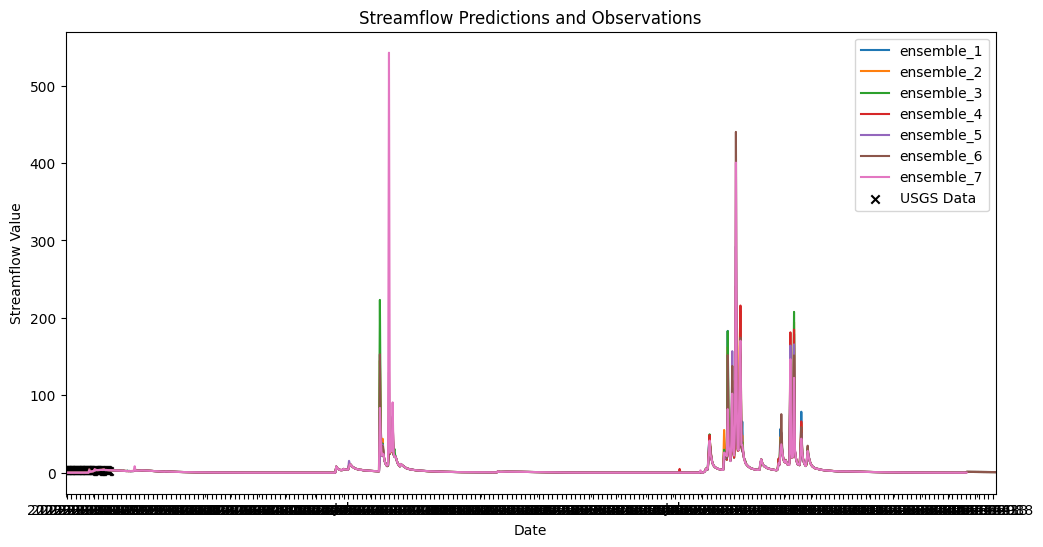

In [36]:
import matplotlib.dates as mdates

# Your ensemble_data and usgs_data are assumed to be already populated

# Convert ensemble_data to a DataFrame
ensemble_df = pd.DataFrame(ensemble_data)

# Create a date range for ensemble data
date_range_ensemble = pd.date_range(start=start_date, periods=len(ensemble_df), freq='D')

# Assign the date range as the index
ensemble_df['date'] = date_range_ensemble
ensemble_df.set_index('date', inplace=True)

# Plotting
plt.figure(figsize=(12, 6))

# Plot ensemble data
ensemble_df.plot(ax=plt.gca())

# Convert Pandas datetime to Matplotlib's numeric representation
usgs_data['timestamp_numeric'] = mdates.date2num(usgs_data['timestamp'])

# Scatter plot for USGS data using numeric representation
plt.scatter(usgs_data['timestamp_numeric'], usgs_data['data0'], c='black', marker='x', label='USGS Data')

# Set x-axis to display datetime format
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))

plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('Streamflow Value')
plt.title('Streamflow Predictions and Observations')
plt.show()


In [40]:
from datetime import date, timedelta
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Initialize a dictionary to store the streamflow values for each ensemble
ensemble_data = {
    'ensemble_1': [],
    'ensemble_2': [],
    'ensemble_3': [],
    'ensemble_4': [],
    'ensemble_5': [],
    'ensemble_6': [],
    'ensemble_7': [],
}

# Define the time delta of 1 day
delta = timedelta(days=1)

# Loop through each date
start_date = date(2023, 8, 20)
end_date = date(2023, 10, 20)
current_date = start_date

while current_date <= end_date:
    date_str = current_date.strftime("%Y%m%d")
    
    # Loop through each ensemble number
    for ensemble_num in range(1, 8):
        file_path = os.path.join("/home/antonio/UCSC/Research/NWM_channel_hydrofabric", f"nwm.t00z.medium_range.channel_rt_{ensemble_num}.f024.conus_mem{ensemble_num}_{date_str}.nc")
        
        if os.path.exists(file_path):
            streamflow_value = extract_streamflow(file_path)  # Replace with your actual function
            ensemble_data[f'ensemble_{ensemble_num}'].append(streamflow_value)
            
    current_date += delta

# Convert ensemble_data to DataFrame
ensemble_df = pd.DataFrame(ensemble_data)

# Load USGS data
usgs_file_path = '/home/antonio/UCSC/Research/USGS river data/San Lorenzo River at Big Trees/San_Lorenzo_Daily_USGS_R.csv'
usgs_data = pd.read_csv(usgs_file_path)
usgs_data['timestamp'] = pd.to_datetime(usgs_data['timestamp'])

# Data transformation: add 1 and take the logarithm
ensemble_df = ensemble_df.apply(lambda x: np.log(x + 1))
usgs_data['data0'] = np.log(usgs_data['data0'] + 1)

# Plotting
plt.figure(figsize=(12, 6))

# Plot ensemble data
ensemble_df.plot(ax=plt.gca())

# Convert Pandas datetime to Matplotlib's numeric representation
usgs_data['timestamp_numeric'] = mdates.date2num(usgs_data['timestamp'])

# Scatter plot for USGS data using numeric representation
plt.scatter(usgs_data['timestamp_numeric'], usgs_data['data0'], c='black', marker='x', label='USGS Data')

# Set x-axis to display datetime format and adjust to have markers for every month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('Transformed Streamflow Value')
plt.title('Transformed Streamflow Predictions and Observations')
plt.show()


TypeError: extract_streamflow() missing 1 required positional argument: 'feature_id'